# Nutritional Products Sales Breakdown

## Table of Contents <a id='back'></a>
- [Project Introduction](#project-introduction)
    - [Analysis Outline](#analysis-outline)
    - [Executive Summary](#executive-summary)
- [Importing Libraries and Opening Data Files](#importing-libraries-and-opening-data-files)
- [Data Wrangling](#data-wrangling)
    - [Duplicates](#duplicates)
    - [Missing Values](#missing-values)
    - [Data Transformation](#data-transformation)
    - [Removing Irrelevant Data](#removing-irrelevant-data)
- [Exploratory Data Analysis](#exploratory-data-analysis)
- [Conclusions and Reccomendations](#conclusions-and-reccomendations)
- [Dataset Citation](#dataset-citation)

## Project Introduction

[project intro]

### Analysis Outline

[Analysis Outline]

### Executive Summary

[Results]


[Back to Table of Contents](#back)

## Importing Libraries and Opening Data Files

In [1]:
# Importing the needed libraries for this assignment
import pandas as pd
import mysql.connector
from matplotlib import pyplot as plt
import seaborn as sns
import folium
from geopy.geocoders import Nominatim
import requests

In [ ]:
# Importing data from MySQL
try:
    conn = mysql.connector.connect(
        user='root',
        password='password', # password
        host='localhost',
        database='supplement_sales',
        port=3306)

except:
    conn = mysql.connector.connect(
        user='root',
        password='password', # password
        host='localhost',
        database='supplement_sales',
        port=3306)

In [3]:
# Using pandas to save the data from MySQL to a Python DataFrame for later data manipulation
df = pd.read_sql('SELECT * FROM supp_weekly_sales_cleaned', conn)

df.info()
df.head()

C:\Users\jason\AppData\Local\Temp\ipykernel_10756\418239610.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql('SELECT * FROM supp_weekly_sales_cleaned', conn)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4384 entries, 0 to 4383
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   week_date       4384 non-null   object 
 1   product_name    4384 non-null   object 
 2   category        4384 non-null   object 
 3   units_sold      4384 non-null   int64  
 4   price           4384 non-null   int64  
 5   total_revenue   4384 non-null   int64  
 6   discount        4384 non-null   float64
 7   units_returned  4384 non-null   int64  
 8   location        4384 non-null   object 
 9   platform        4384 non-null   object 
dtypes: float64(1), int64(4), object(5)
memory usage: 342.6+ KB


,week_date,product_name,category,units_sold,price,total_revenue,discount,units_returned,location,platform
0,2020-01-06,whey_protein,protein,143,32,4573,0.03,2,canada,walmart
1,2020-01-06,vitamin_c,vitamin,139,43,5909,0.04,0,uk,amazon
2,2020-01-06,fish_oil,omega,161,13,2079,0.25,0,canada,amazon
3,2020-02-24,ashwagandha,herbal,133,27,3612,0.18,2,uk,iherb
4,2020-01-06,multivitamin,vitamin,140,16,2250,0.08,0,canada,walmart


[Back to Table of Contents](#back)

## Data Wrangling

### Duplicates

In [4]:
# Checking for duplicates
df.duplicated().sum()

0

[Back to Table of Contents](#back)

### Missing Values

In [5]:
# Checking for null values
df.isna().sum()

week_date         0
product_name      0
category          0
units_sold        0
price             0
total_revenue     0
discount          0
units_returned    0
location          0
platform          0
dtype: int64

[Back to Table of Contents](#back)

### Data Transformation

In [6]:
# Getting general information about the dataset
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4384 entries, 0 to 4383
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   week_date       4384 non-null   object 
 1   product_name    4384 non-null   object 
 2   category        4384 non-null   object 
 3   units_sold      4384 non-null   int64  
 4   price           4384 non-null   int64  
 5   total_revenue   4384 non-null   int64  
 6   discount        4384 non-null   float64
 7   units_returned  4384 non-null   int64  
 8   location        4384 non-null   object 
 9   platform        4384 non-null   object 
dtypes: float64(1), int64(4), object(5)
memory usage: 342.6+ KB


,week_date,product_name,category,units_sold,price,total_revenue,discount,units_returned,location,platform
0,2020-01-06,whey_protein,protein,143,32,4573,0.03,2,canada,walmart
1,2020-01-06,vitamin_c,vitamin,139,43,5909,0.04,0,uk,amazon
2,2020-01-06,fish_oil,omega,161,13,2079,0.25,0,canada,amazon
3,2020-02-24,ashwagandha,herbal,133,27,3612,0.18,2,uk,iherb
4,2020-01-06,multivitamin,vitamin,140,16,2250,0.08,0,canada,walmart


In [7]:
#checking for snakecase format
df.columns

Index(['week_date', 'product_name', 'category', 'units_sold', 'price',
       'total_revenue', 'discount', 'units_returned', 'location', 'platform'],
      dtype='object')

Observation:

- 

In [8]:
# Converting week_date column into datetime data type for later extraction and manipulation
df['week_date'] = pd.to_datetime(df['week_date'], format='%Y-%m-%d')

# Extracting week, month, quarter, and year values from week_date column
df['week'] = df['week_date'].dt.isocalendar().week
df['month'] = df['week_date'].dt.month
df['quarter'] = df['week_date'].dt.quarter
df['year'] = df['week_date'].dt.year

In [9]:
# Looking at the value ranges for the numeric columns and see if there are any outliers or entry errors
print(f'Max units sold: {df['units_sold'].max()}')
print(f'Min units sold: {df['units_sold'].min()}')
print(f'Max price: {df['price'].max()}')
print(f'Min price: {df['price'].min()}')
print(f'Max total revenue: {df['total_revenue'].max()}')
print(f'Min total revenue: {df['total_revenue'].min()}')
print(f'Max units returned: {df['units_returned'].max()}')
print(f'Min units returned: {df['units_returned'].min()}')

Max units sold: 194
Min units sold: 103
Max price: 60
Min price: 10
Max total revenue: 10762
Min total revenue: 1284
Max units returned: 8
Min units returned: 0


Observation:

- 

In [10]:
# Calculating percentiles and interquartile range
q1 = df['units_sold'].quantile(0.25)
q3 = df['units_sold'].quantile(0.75)
iqr = q3 - q1

# Calculating upper and lower limit
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

# Filtering for outliers
outliers = df[(df['units_sold'] < lower) | (df['units_sold'] > upper)]
print(f' Percentage of outliers: {round(((len(outliers) / len(df)) * 100), 2)}%')
print(outliers)

 Percentage of outliers: 0.91%
      week_date        product_name     category  units_sold  price  \
20   2020-03-02        multivitamin      vitamin         184     12   
175  2020-02-03                zinc      mineral         184     36   
341  2020-04-06         pre_workout  performance         116     53   
354  2020-04-06  electrolyte_powder    hydration         185     43   
360  2020-02-17   green_tea_extract   fat_burner         117     27   
385  2020-04-20                zinc      mineral         188     30   
461  2020-11-16            fish_oil        omega         194     51   
540  2020-11-30     iron_supplement      mineral         184     25   
569  2021-02-01         ashwagandha       herbal         186     35   
602  2020-12-14         ashwagandha       herbal         185     27   
764  2021-05-10        multivitamin      vitamin         184     13   
960  2020-07-27           vitamin_c      vitamin         183     34   
966  2021-07-12  electrolyte_powder    hydrati

Observation:

- 

In [11]:
# Saving the new cleaned dataset if needed
#df.to_csv('cleaned_data.csv', index=False)

[Back to Table of Contents](#back)

## Exploratory Data Analysis

In [12]:
df.head()

,week_date,product_name,category,units_sold,price,total_revenue,discount,units_returned,location,platform,week,month,quarter,year
0,2020-01-06,whey_protein,protein,143,32,4573,0.03,2,canada,walmart,2,1,1,2020
1,2020-01-06,vitamin_c,vitamin,139,43,5909,0.04,0,uk,amazon,2,1,1,2020
2,2020-01-06,fish_oil,omega,161,13,2079,0.25,0,canada,amazon,2,1,1,2020
3,2020-02-24,ashwagandha,herbal,133,27,3612,0.18,2,uk,iherb,9,2,1,2020
4,2020-01-06,multivitamin,vitamin,140,16,2250,0.08,0,canada,walmart,2,1,1,2020


### Time-Based Exploration

#### Monthly Trends

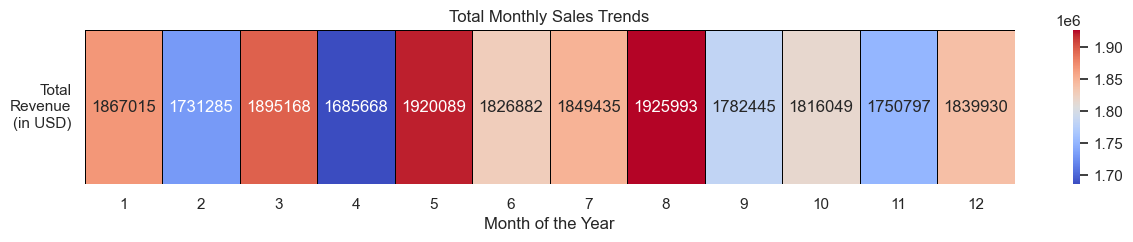

In [46]:
# Setting theme and figure size for graphs
sns.set_theme(style='darkgrid')
plt.figure(figsize=(15, 2))

# Filtering for full years only so monthly data does not skew
df_full = df[df['year'] < 2025] 
# Creating and plotting a pivot table of monthly sales per year
monthly_trends = df_full.pivot_table(columns='month',
                                     values='total_revenue',
                                     aggfunc='sum')
# Creating a heatmap for the pivot table data
ax = sns.heatmap(monthly_trends,
                 cmap='coolwarm',
                 annot=True,
                 fmt='.0f',
                 linewidths=.5,
                 linecolor='black')
ax.set_title('Total Monthly Sales Trends')
ax.set_xlabel('Month of the Year')
ax.set_yticklabels(['Total\nRevenue\n(in USD)'], rotation=360)
plt.show()

Observation:

- 

#### Annual Trends

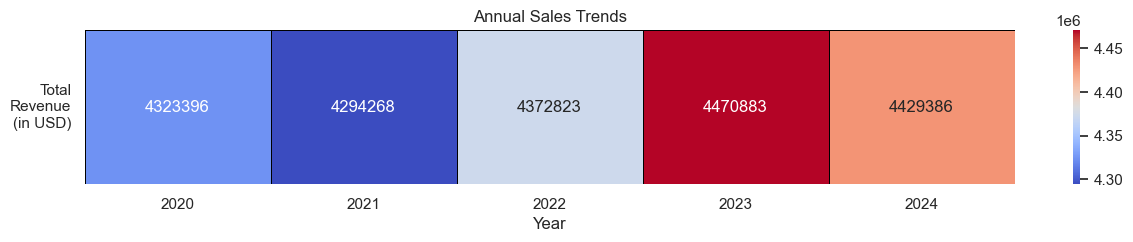

In [48]:
# Setting theme and figure size for graphs
sns.set_theme(style='darkgrid')
plt.figure(figsize=(15, 2))

# Creating and plotting a pivot table of monthly sales per year
yearly_trends = df_full.pivot_table(columns='year',
                                    values='total_revenue',
                                    aggfunc='sum')
# Creating a heatmap for the pivot table data
ax = sns.heatmap(yearly_trends,
                 cmap='coolwarm',
                 annot=True,
                 fmt='.0f',
                 linewidths=.5,
                 linecolor='black')
ax.set_title('Annual Sales Trends')
ax.set_xlabel('Year')
ax.set_yticklabels(['Total\nRevenue\n(in USD)'], rotation=360)
plt.show()

[Back to Table of Contents](#back)

## Conclusions and Reccomendations



[Back to Table of Contents](#back)

## Dataset Citation

Zahid Feroze. (2025, November). Supplement Sales Data, Version 1. Retrieved November 3, 2025 from [Kaggle](https://www.kaggle.com/datasets/zahidmughal2343/supplement-sales-data)

[Back to Table of Contents](#back)